# 1. Dataset Loading and Cleaning

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("telecom_data.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).copy()

df = df.drop(columns=["customerID"])

df["Churn_binary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


# 2. EDA relevant to linear regression assumptions.

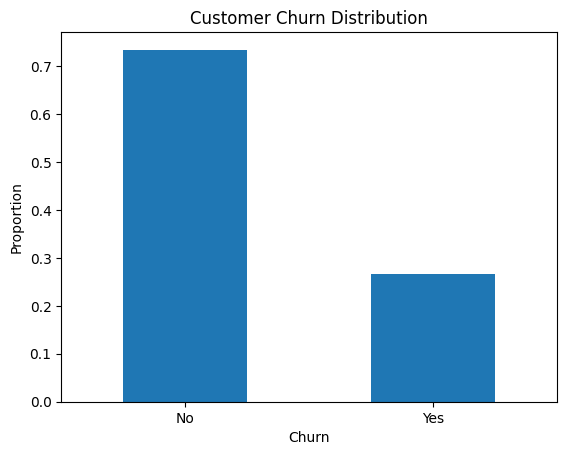

In [59]:
df["Churn"].value_counts(normalize=True).plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

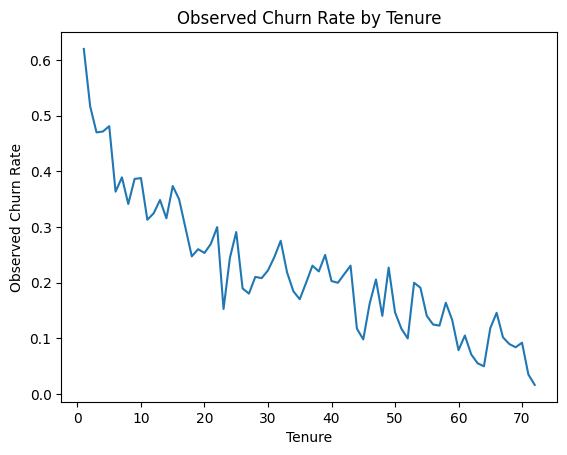

In [60]:
tenure_churn = df.groupby("tenure")["Churn_binary"].mean()

tenure_churn.plot()

plt.title("Observed Churn Rate by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Observed Churn Rate")
plt.show()

# 3. Linear regression model code.

In [ ]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "TechSupport"
]

X = df[features]
y = df["Churn_binary"]

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


# 4. Model Performance Evidence


In [62]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Minimum prediction: {y_pred.min():.4f}")
print(f"Maximum prediction: {y_pred.max():.4f}")

MSE: 0.1490
R²: 0.2366
Minimum prediction: -0.1131
Maximum prediction: 0.7198


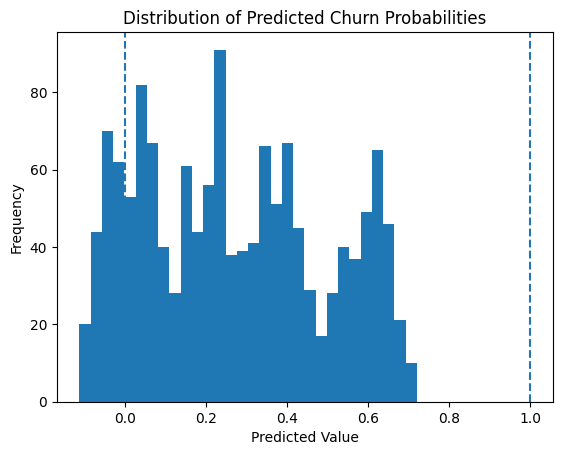

In [63]:
plt.hist(y_pred, bins=30)

plt.axvline(0, linestyle="--")
plt.axvline(1, linestyle="--")

plt.title("Distribution of Predicted Churn Probabilities")
plt.xlabel("Predicted Value")
plt.ylabel("Frequency")
plt.show()

# 5. Coefficient Interpretation

In [64]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

coef_df

,Feature,Coefficient
5,InternetService_Fiber optic,0.149777
3,Contract_One year,-0.145715
4,Contract_Two year,-0.114365
8,TechSupport_Yes,-0.088461
7,TechSupport_No internet service,-0.050424
6,InternetService_No,-0.050424
1,MonthlyCharges,0.003055
0,tenure,-0.001280
2,TotalCharges,-0.000052


Since churn is coded as 0 and 1, the coefficients represent changes in predicted churn probability. Fiber optic internet has the largest positive coefficient (0.150), suggesting about a 15 percentage-point higher predicted churn probability compared with the reference internet service. One-year and two-year contracts have negative coefficients (-0.146 and -0.114), suggesting lower predicted churn probability compared with the reference contract type. Having tech support is also associated with a lower predicted churn probability (-0.088).

# 6. Limitations of Linear Regression for Churn

One limitation is that linear regression can produce invalid probabilities for a binary outcome like churn. In our model, the minimum predicted value was -0.1131, which cannot represent a valid churn probability. Therefore, although the coefficients are easy to interpret, linear regression is not ideal for modeling churn.